In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# here's the great entry of our data preprocessing

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# now normalising the pixel values between 0 to 1 coz we all know neural nets hates large values, so we scale them down

In [5]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [6]:
# now the below step is gonna b really imp change for CNNs

In [7]:
# we change the shape to b 28, 28, 1 where 1 stands for singular color i.e. grayscale (if it would b colored RGB then would have been 28, 28, 3. but we dont need to complicate this)

In [8]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [9]:
# performing one hot encoding now (not label to avoid indirect unwanted biasness)(IYKYK)

In [10]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [11]:
# time to build our model
# CNN jindabaad

In [12]:
model = models.Sequential(
    [
        # this is our 1st conv block using 32 filters and relu. we also downsample to reduce overfitting.
        layers.Conv2D(32, (3, 3), activation = 'relu', padding = 'same', input_shape = (28, 28, 1)),
        layers.MaxPooling2D((2, 2)),

        # now our 2nd conv block, but we'll double the filters to learn more complex features keeping the relu same
        layers.Conv2D(64, (3, 3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2, 2)),

        # before forming the dense layer, we need to flatten to uk convert the 2d to 1d vector, soooo...
        layers.Flatten(),

        # now the interesting part, Dense Hidden Layer with 128 neurons and a bit aggressive droupout to prevent overfitting
        layers.Dense(128, activation = 'relu'),
        layers.Dropout(0.5),

        # output layer, we need 10 neurons as in 1 per category
        layers.Dense(10, activation = 'softmax')
    ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# our next imp step is to let the model learn i.e. Training and compilation

model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate = 0.01, momentum = 0.9),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(
    x_train, y_train_cat,
    epochs = 10,
    batch_size = 64,
    validation_split = 0.1,
    verbose = 1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8743 - loss: 0.3922 - val_accuracy: 0.9790 - val_loss: 0.0738
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9623 - loss: 0.1271 - val_accuracy: 0.9860 - val_loss: 0.0493
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9726 - loss: 0.0899 - val_accuracy: 0.9875 - val_loss: 0.0416
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9780 - loss: 0.0734 - val_accuracy: 0.9908 - val_loss: 0.0361
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9806 - loss: 0.0615 - val_accuracy: 0.9900 - val_loss: 0.0423
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9832 - loss: 0.0552 - val_accuracy: 0.9910 - val_loss: 0.0337
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9846 - loss: 0.0490 - val_accuracy: 0.9905 - val_loss: 0.0343
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0

In [14]:
# Evaluation timeeeee

test_loss, test_acc = model .evaluate(x_test, y_test_cat, verbose = 0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}, That's {test_acc*100:.2f}%! Pretty solid ig.")

Test Loss: 0.0258
Test Accuracy: 0.9905, That's 99.05%! Pretty solid ig.


In [15]:
# Prediction_functionality

def predict_digits(model, images):
  """
  this will take the model and sm images , handle reshape automatically if we pass in raw 28*28 images and return prediction and confidence scores.
  """
  # checking if input needs reshaping
  if len(images.shape) == 2:
    images = images.reshape(-1, 28, 28, 1)
  elif len(images.shape) == 3 and images.shape[-1] != 1:
    # if its N, 28, 28 we add the channel dim
    images = images.reshape(-1, 28, 28, 1)

  # getting probabilities here
  probs = model.predict(images, verbose = 0)

  # but we need the class wid highest prob, sooo...
  predictions = np.argmax(probs, axis = 1)

  return predictions, probs

# q very quick mini test on first 5 images

sample_imgs = x_test[:30]
true_labels = y_test[:30]
preds, confidences = predict_digits(model, sample_imgs)

print("\nSample Predictions:")
for i in range(30):
    print(f"Image {i}: True={true_labels[i]}, Pred={preds[i]} ({confidences[i][preds[i]]:.1%} sure)")



Sample Predictions:
Image 0: True=7, Pred=7 (100.0% sure)
Image 1: True=2, Pred=2 (100.0% sure)
Image 2: True=1, Pred=1 (100.0% sure)
Image 3: True=0, Pred=0 (100.0% sure)
Image 4: True=4, Pred=4 (100.0% sure)
Image 5: True=1, Pred=1 (100.0% sure)
Image 6: True=4, Pred=4 (99.1% sure)
Image 7: True=9, Pred=9 (100.0% sure)
Image 8: True=5, Pred=5 (99.9% sure)
Image 9: True=9, Pred=9 (100.0% sure)
Image 10: True=0, Pred=0 (100.0% sure)
Image 11: True=6, Pred=6 (100.0% sure)
Image 12: True=9, Pred=9 (100.0% sure)
Image 13: True=0, Pred=0 (100.0% sure)
Image 14: True=1, Pred=1 (100.0% sure)
Image 15: True=5, Pred=5 (100.0% sure)
Image 16: True=9, Pred=9 (100.0% sure)
Image 17: True=7, Pred=7 (100.0% sure)
Image 18: True=3, Pred=3 (78.5% sure)
Image 19: True=4, Pred=4 (100.0% sure)
Image 20: True=9, Pred=9 (100.0% sure)
Image 21: True=6, Pred=6 (100.0% sure)
Image 22: True=6, Pred=6 (100.0% sure)
Image 23: True=5, Pred=5 (100.0% sure)
Image 24: True=4, Pred=4 (100.0% sure)
Image 25: True=0,

In [15]:
# time to analyse and vizualise

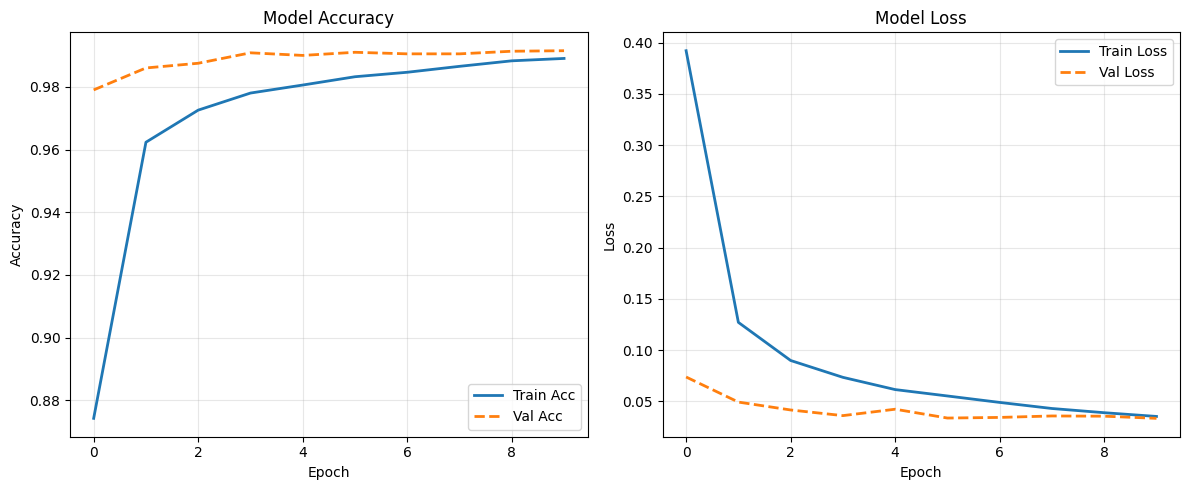

In [16]:
# Plot Training vs Validation curves
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Acc', linestyle='--', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

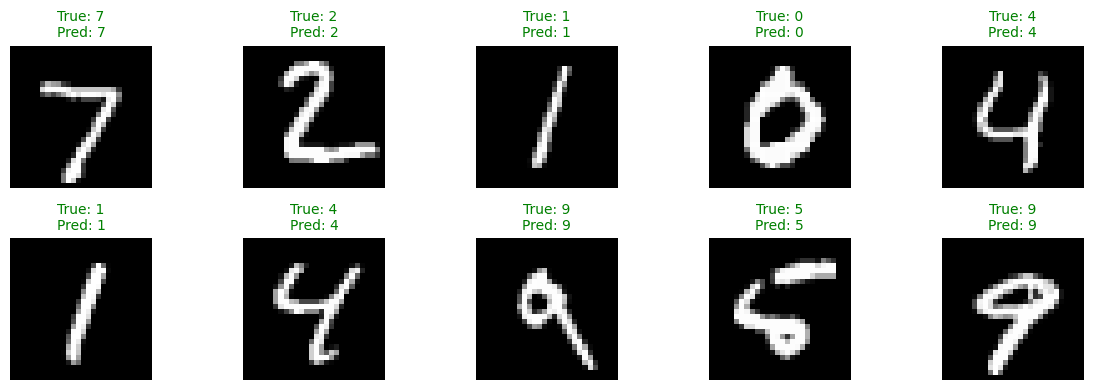

In [17]:
# Visualize predictions (Green = Correct, Red = Wrong)
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)

    # Grab image and reshape for display (remove channel dim)
    img_display = x_test[i].reshape(28, 28)
    plt.imshow(img_display, cmap='gray')

    true_val = y_test[i]
    pred_val = preds[i] if i < len(preds) else predict_digits(model, x_test[i:i+1])[0][0]

    color = 'green' if true_val == pred_val else 'red'
    plt.title(f"True: {true_val}\nPred: {pred_val}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
# We r done here with A3!